# Diagnostic Analysis — NVIDIA

Two diagnostic pillars, both non-causal: **Pillar 1** dates structural breaks in NVIDIA's
price and fundamentals; **Pillar 2** measures how NVIDIA's return co-movement with Intel,
AMD, and the Nasdaq-100 decouples across the three eras.

## Pillar 1 · Structural-break detection

This pillar dates the regime changes in
NVIDIA's market price and fundamentals and asks *where they fall relative to the three
AI milestones* — AlexNet (2012Q3), the Transformer (2017Q3), and ChatGPT (2022Q4).

**This is a non-causal, temporal-alignment analysis.** The tests below identify *when*
each series changes regime and *how confidently* the break is dated. They say nothing
about *why*. A break that coincides with a milestone is consistent with — but is not
evidence of — that milestone causing the shift; crypto cycles, COVID, and the broad
macro/semiconductor cycle move in the same windows and are kept visible as confounder
bands throughout. We therefore read every result as *alignment*, never as causation.

We run two complementary tests on each series:

* **Bai–Perron** — a global, dynamic-programming search for an *unknown number* of
  breaks at *unknown dates*, with the number of breaks selected by BIC and cross-checked
  with sequential sup-*F* tests. Answers: *how many* regime changes, and *where*.
* **Quandt–Andrews** — a sup-Wald test for a *single* unknown break: it computes the
  Chow *F* at every admissible date and takes the supremum. Answers: *the single most
  significant* inflection. It complements Bai–Perron — where the true structure has
  several breaks, Quandt–Andrews reports the dominant one.

Both use 15% symmetric trimming and wild-bootstrap *p*-values (Rademacher, residuals
resampled under the relevant null), so significance does not rely on tabulated
asymptotic critical values. Break-date confidence intervals are bootstrapped.

In [1]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "Source" / "common.py").exists():
        sys.path.insert(0, str(_p / "Source")); break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import common

common.apply_style()
RNG = np.random.default_rng(42)        # reproducible bootstraps
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

panel = common.load_panel()
nvda = panel[panel["ticker"] == "NVDA"].sort_values("calendar_quarter").set_index("calendar_quarter")
print("NVDA quarters:", nvda.index.min(), "->", nvda.index.max(), f"({len(nvda)} rows)")

NVDA quarters: 2010Q1 -> 2026Q1 (65 rows)


## Methods

The estimator is a textbook Bai–Perron global minimiser plus a Quandt–Andrews sup-Wald,
both implemented directly so the regression specification per series is explicit.

* **Price → log level, *trend* model** (`q=2`: regress on `[1, t]` within each regime).
  A break = a change in the slope of log-price, i.e. a change in the compound growth
  trajectory ("re-rating"). Price has no quarterly seasonality, so the level is used.
* **Revenue & net income → year-over-year log growth, *mean* model** (`q=1`: regress on
  a constant). YoY differencing (`log Xₜ − log Xₜ₋₄`) removes quarterly seasonality
  (like-quarter vs like-quarter) and stationarises the series; a break = a shift in the
  average growth rate. Net income has a single loss quarter (2010Q2) where a log is
  undefined, so that quarter is dropped and the growth series runs contiguously from
  2011Q3.

`bai_perron` returns the BIC-selected break count, all candidate models, sequential
sup-*F* statistics with bootstrap *p*-values, and bootstrapped break-date CIs.
`quandt_andrews` returns the single sup-Wald break with its sup/ave/exp-*F* statistics
and a bootstrap *p*-value.

In [2]:
# ----------------------------- design ------------------------------ #
def _design(n, q):
    t = np.arange(n)
    return np.column_stack([np.ones(n), t]) if q == 2 else np.ones((n, 1))

def _ssr(y, X):
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    r = y - X @ b
    return float(r @ r)

def _ssr_matrix(y, q):
    n = len(y); X = _design(n, q)
    M = np.full((n, n), np.inf)
    for i in range(n):
        for j in range(i, n):
            if j - i + 1 >= q:
                M[i, j] = _ssr(y[i:j+1], X[i:j+1])
    return M

def _dp(M, n, m, h):
    '''Min-SSR partition into m+1 segments, each length >= h.'''
    if m == 0:
        return M[0, n-1], []
    cost = np.full((m+2, n), np.inf); pos = np.full((m+2, n), -1, int)
    for e in range(h-1, n):
        cost[1, e] = M[0, e]
    for k in range(2, m+2):
        for e in range(k*h-1, n):
            for b in range((k-1)*h-1, e-h+1):
                c = cost[k-1, b] + M[b+1, e]
                if c < cost[k, e]:
                    cost[k, e] = c; pos[k, e] = b
    bps = []; e = n-1; k = m+1
    while k > 1:
        b = pos[k, e]; bps.append(b); e = b; k -= 1
    return cost[m+1, n-1], [b+1 for b in sorted(bps)]   # break index = first obs of new regime

# --------------------------- Bai-Perron ---------------------------- #
def bai_perron(y, q, mmax=5, trim=0.15, reps=300):
    n = len(y); h = max(q, int(np.floor(trim*n)))
    M = _ssr_matrix(y, q)
    rows = []
    for m in range(mmax+1):
        if (m+1)*h > n:
            break
        ssr, bps = _dp(M, n, m, h)
        pstar = (m+1)*q + m
        bic = n*np.log(ssr/n) + pstar*np.log(n)
        rows.append({"m": m, "ssr": ssr, "bic": bic, "breaks": bps})
    mstar = min(rows, key=lambda r: r["bic"])["m"]
    ssr_by_m = {r["m"]: r["ssr"] for r in rows}

    def seqF(l):
        sl, sl1 = ssr_by_m[l], ssr_by_m[l+1]
        return (sl - sl1) / (sl1 / (n - (l+2)))

    def boot_p_seq(l, Fobs):
        X = _design(n, q); bps = next(r["breaks"] for r in rows if r["m"] == l)
        edges = [0] + bps + [n]; fit = np.zeros(n); res = np.zeros(n)
        for a, b in zip(edges[:-1], edges[1:]):
            beta, *_ = np.linalg.lstsq(X[a:b], y[a:b], rcond=None)
            fit[a:b] = X[a:b] @ beta; res[a:b] = y[a:b] - X[a:b] @ beta
        c = 0
        for _ in range(reps):
            ys = fit + res*RNG.choice([-1., 1.], n); Mb = _ssr_matrix(ys, q)
            sl, _ = _dp(Mb, n, l, h); sl1, _ = _dp(Mb, n, l+1, h)
            if (sl - sl1)/(sl1/(n-(l+2))) >= Fobs:
                c += 1
        return (c+1)/(reps+1)

    supF = {}
    for l in range(max(ssr_by_m)):
        if l+1 not in ssr_by_m:
            break
        F = seqF(l); supF[l+1] = {"F": F, "p": boot_p_seq(l, F)}

    # bootstrap break-date CIs for the BIC-selected model
    ci = []
    if mstar > 0:
        X = _design(n, q); bps = next(r["breaks"] for r in rows if r["m"] == mstar)
        edges = [0] + bps + [n]; fit = np.zeros(n); res = np.zeros(n)
        for a, b in zip(edges[:-1], edges[1:]):
            beta, *_ = np.linalg.lstsq(X[a:b], y[a:b], rcond=None)
            fit[a:b] = X[a:b] @ beta; res[a:b] = y[a:b] - X[a:b] @ beta
        samp = [[] for _ in bps]
        for _ in range(reps):
            ys = fit + res*RNG.choice([-1., 1.], n); Mb = _ssr_matrix(ys, q)
            _, bb = _dp(Mb, n, mstar, h)
            if len(bb) == mstar:
                for i, bp in enumerate(bb):
                    samp[i].append(bp)
        ci = [tuple(np.percentile(s, [5, 95]).round().astype(int)) for s in samp]
    return {"rows": rows, "mstar": mstar, "breaks": next(r["breaks"] for r in rows if r["m"] == mstar),
            "ci": ci, "supF": supF, "h": h, "n": n}

# ------------------------- Quandt-Andrews -------------------------- #
def quandt_andrews(y, q, trim=0.15, reps=500):
    n = len(y); X = _design(n, q); Sfull = _ssr(y, X)
    k0 = int(np.floor(trim*n)); k1 = n - k0
    F = np.full(n, np.nan)
    for k in range(k0, k1):
        Su = _ssr(y[:k], X[:k]) + _ssr(y[k:], X[k:])
        F[k] = ((Sfull - Su)/q) / (Su/(n - 2*q))
    kstar = int(np.nanargmax(F)); supF = float(F[kstar])
    v = F[~np.isnan(F)]; aveF = float(v.mean()); expF = float(np.log(np.mean(np.exp(0.5*v))))
    # wild bootstrap under no-break null
    b, *_ = np.linalg.lstsq(X, y, rcond=None); fit = X @ b; res = y - fit
    c = 0
    for _ in range(reps):
        ys = fit + res*RNG.choice([-1., 1.], n); Sf = _ssr(ys, X); best = -np.inf
        for k in range(k0, k1):
            Su = _ssr(ys[:k], X[:k]) + _ssr(ys[k:], X[k:])
            best = max(best, ((Sf - Su)/q)/(Su/(n-2*q)))
        if best >= supF:
            c += 1
    return {"kstar": kstar, "supF": supF, "aveF": aveF, "expF": expF, "p": (c+1)/(reps+1)}

print("methods defined")

methods defined


## Series construction

The three series follow the confirmed specification. We also keep a `date` per
observation (quarter-end) so breaks can be drawn on the era/milestone timeline.

In [3]:
def qdate(q):                      # 'YYYYQn' -> quarter-end timestamp (matches panel 'date')
    return pd.Period(q, "Q").end_time.normalize()

# Price: log level, full history
price = nvda["qend_adj_close"].dropna()
S_price = {"name": "log(price)", "model": "trend", "q": 2,
          "y": np.log(price.values), "q_labels": list(price.index)}

# Revenue: YoY log growth
rev_log = np.log(nvda["revenue"].dropna())
rev_yoy = (rev_log - rev_log.shift(4)).dropna()
S_rev = {"name": "YoY log revenue growth", "model": "mean", "q": 1,
         "y": rev_yoy.values, "q_labels": list(rev_yoy.index)}

# Net income: drop the single 2010Q2 loss, YoY log growth, contiguous from 2011Q3
ni = nvda["net_income"].dropna().astype(float)
ni_log = np.log(ni.where(ni > 0))               # 2010Q2 (loss) -> NaN
ni_yoy = (ni_log - ni_log.shift(4)).loc["2011Q3":].dropna()
S_ni = {"name": "YoY log net-income growth", "model": "mean", "q": 1,
        "y": ni_yoy.values, "q_labels": list(ni_yoy.index)}

for S in (S_price, S_rev, S_ni):
    print(f"{S['name']:28} n={len(S['y']):3}  {S['q_labels'][0]} .. {S['q_labels'][-1]}  ({S['model']} model)")

log(price)                   n= 65  2010Q1 .. 2026Q1  (trend model)
YoY log revenue growth       n= 60  2011Q1 .. 2025Q4  (mean model)
YoY log net-income growth    n= 58  2011Q3 .. 2025Q4  (mean model)


In [4]:
def run_series(S):
    bp = bai_perron(S["y"], S["q"]); qa = quandt_andrews(S["y"], S["q"])
    ql = S["q_labels"]
    bp_breaks = [ql[b] for b in bp["breaks"]]
    bp_ci = [(ql[max(0,lo)], ql[min(len(ql)-1,hi)]) for (lo,hi) in bp["ci"]]
    qa_break = ql[qa["kstar"]]
    S.update(bp=bp, qa=qa, bp_breaks=bp_breaks, bp_ci=bp_ci, qa_break=qa_break)
    return S

def bp_table(S):
    ql = S["q_labels"]; rows = []
    for r in S["bp"]["rows"]:
        bq = ", ".join(ql[b] for b in r["breaks"]) if r["breaks"] else "—"
        rows.append({"m (breaks)": r["m"], "SSR": round(r["ssr"], 4),
                     "BIC": round(r["bic"], 2), "break quarters": bq,
                     "BIC-selected": "◀" if r["m"] == S["bp"]["mstar"] else ""})
    return pd.DataFrame(rows)

def supF_table(S):
    rows = []
    for l, d in S["bp"]["supF"].items():
        rows.append({"sequential test": f"supF({l}|{l-1})",
                     "F": round(d["F"], 2), "boot p": round(d["p"], 3)})
    return pd.DataFrame(rows)

def fitted_curve(S):
    '''Piecewise fit for plotting (trend lines or segment means).'''
    y = S["y"]; n = len(y); X = _design(n, S["q"])
    edges = [0] + S["bp"]["breaks"] + [n]; fit = np.full(n, np.nan)
    for a, b in zip(edges[:-1], edges[1:]):
        beta, *_ = np.linalg.lstsq(X[a:b], y[a:b], rcond=None)
        fit[a:b] = X[a:b] @ beta
    return fit

def plot_series(S, fname, ylabel, title):
    dates = [qdate(q) for q in S["q_labels"]]
    y = S["y"]; fit = fitted_curve(S); col = common.color("NVDA")
    fig, ax = plt.subplots()
    common.annotate(ax, era_labels=False, milestone_labels=True)
    ax.plot(dates, y, color=col, lw=1.6, marker="o", ms=2.6, label=S["name"], zorder=4)
    ax.plot(dates, fit, color="#1a1a1a", lw=1.7, ls="-", alpha=0.85,
            label="Bai–Perron regime fit", zorder=5)
    for i, b in enumerate(S["bp"]["breaks"]):
        d = qdate(S["q_labels"][b])
        ax.axvline(d, color="#c62828", lw=1.6, alpha=0.9, zorder=6,
                   label="Bai–Perron break" if i == 0 else None)
    qd = qdate(S["qa_break"])
    ax.axvline(qd, color="#6a1b9a", lw=1.5, ls=":", alpha=0.9, zorder=6,
               label="Quandt–Andrews break")
    common.style_time_axis(ax, every=2)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(loc="upper left", ncols=2)
    fig.tight_layout(); fig.savefig(FIG / fname); plt.show()
    print("saved", FIG / fname)

print("runner + plotter ready")

runner + plotter ready


## 1 · Market price — `log(price)`, trend model

Tests for changes in the *slope* of log-price (the compound-growth trajectory).

In [5]:
run_series(S_price)
bp_table(S_price)

,m (breaks),SSR,BIC,break quarters,BIC-selected
0,0,15.1602,-86.27,—,
1,1,6.5005,-128.79,2015Q4,
2,2,3.9162,-149.21,"2015Q1, 2018Q4",
3,3,2.4134,-168.15,"2015Q1, 2018Q4, 2022Q2",◀
4,4,2.1834,-162.14,"2012Q4, 2016Q3, 2018Q4, 2022Q2",
5,5,2.2021,-149.06,"2012Q4, 2016Q3, 2018Q4, 2021Q1, 2023Q2",


In [6]:
supF_table(S_price)

,sequential test,F,boot p
0,supF(1|0),83.93,0.003
1,supF(2|1),40.91,0.003
2,supF(3|2),37.98,0.056
3,supF(4|3),6.32,0.063
4,supF(5|4),-0.50,0.213


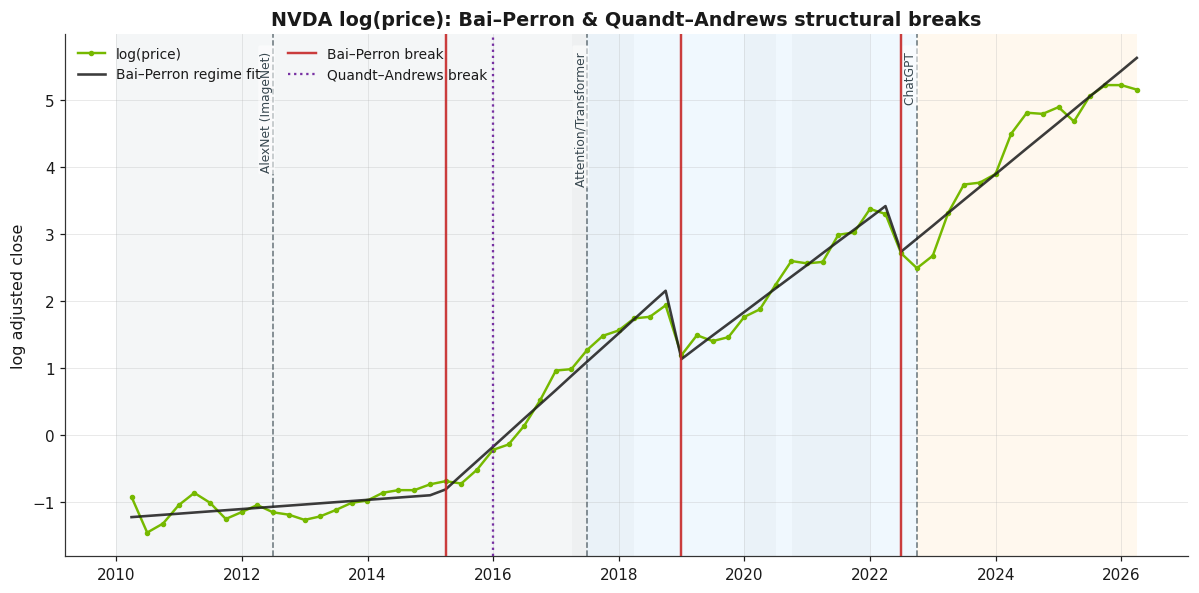

saved figures/12_break_price.png


In [7]:
plot_series(S_price, "12_break_price.png", "log adjusted close",
            "NVDA log(price): Bai–Perron & Quandt–Andrews structural breaks")

**Reading.** Bai–Perron selects **three** trend breaks — **2015Q1, 2018Q4, 2022Q2** —
and Quandt–Andrews puts the single dominant break at **2015Q4**. The price re-rating
therefore *begins in 2015, before the generative-AI era and before the Transformer
marker*. The later two breaks do **not** land on AI milestones: 2018Q4 coincides with
the late-2018 crypto unwind and broad market correction, and 2022Q2 with the 2022
rate-hike sell-off (ChatGPT is two quarters later, 2022Q4). The test dates *when* the
price trajectory changed slope; it cannot attribute those changes, and at least two of
them sit on non-AI confounder windows. We do **not** assign a cause to the 2015 break.

## 2 · Revenue — YoY log growth, mean model

Tests for shifts in the average (deseasonalised) revenue growth rate.

In [8]:
run_series(S_rev)
bp_table(S_rev)

,m (breaks),SSR,BIC,break quarters,BIC-selected
0,0,6.9405,-125.32,—,
1,1,3.6542,-155.63,2023Q2,◀
2,2,3.3536,-152.59,"2016Q2, 2023Q2",
3,3,3.0943,-149.23,"2016Q2, 2018Q3, 2023Q2",
4,4,3.0040,-142.81,"2016Q2, 2018Q3, 2020Q4, 2023Q2",
5,5,2.9922,-134.86,"2014Q1, 2016Q2, 2018Q3, 2020Q4, 2023Q2",


In [9]:
supF_table(S_rev)

,sequential test,F,boot p
0,supF(1|0),52.16,0.003
1,supF(2|1),5.11,0.243
2,supF(3|2),4.69,0.249
3,supF(4|3),1.65,0.209
4,supF(5|4),0.21,0.319


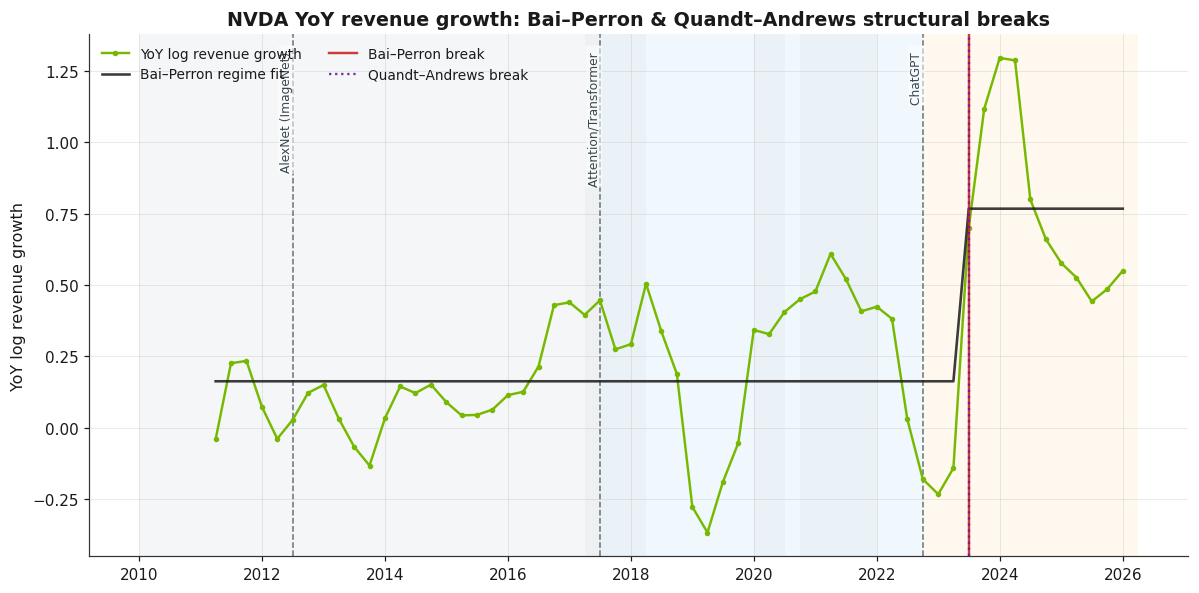

saved figures/13_break_revenue.png


In [10]:
plot_series(S_rev, "13_break_revenue.png", "YoY log revenue growth",
            "NVDA YoY revenue growth: Bai–Perron & Quandt–Andrews structural breaks")

**Reading.** Both tests agree on a **single** break at **2023Q2** (Bai–Perron BIC=1,
the second break rejected; Quandt–Andrews sup-Wald at the same quarter). The 90% CI
reaches back to 2022Q3, straddling the **ChatGPT marker (2022Q4)**. NVIDIA's revenue
growth regime changes exactly once over 2011–2025, and that change aligns in time with
the generative-AI onset.

## 3 · Net income — YoY log growth, mean model

Same specification as revenue; the single 2010Q2 loss quarter is excluded.

In [11]:
run_series(S_ni)
bp_table(S_ni)

,m (breaks),SSR,BIC,break quarters,BIC-selected
0,0,42.2125,-14.37,—,
1,1,32.9429,-20.63,2023Q2,◀
2,2,31.5807,-14.96,"2015Q3, 2023Q2",
3,3,26.3932,-17.24,"2016Q2, 2018Q3, 2023Q2",
4,4,26.1899,-9.57,"2016Q2, 2018Q3, 2020Q3, 2023Q2",
5,5,26.0712,-1.71,"2014Q1, 2016Q2, 2018Q3, 2020Q3, 2023Q2",


In [12]:
supF_table(S_ni)

,sequential test,F,boot p
0,supF(1|0),15.76,0.013
1,supF(2|1),2.37,0.538
2,supF(3|2),10.61,0.027
3,supF(4|3),0.41,0.953
4,supF(5|4),0.24,0.774


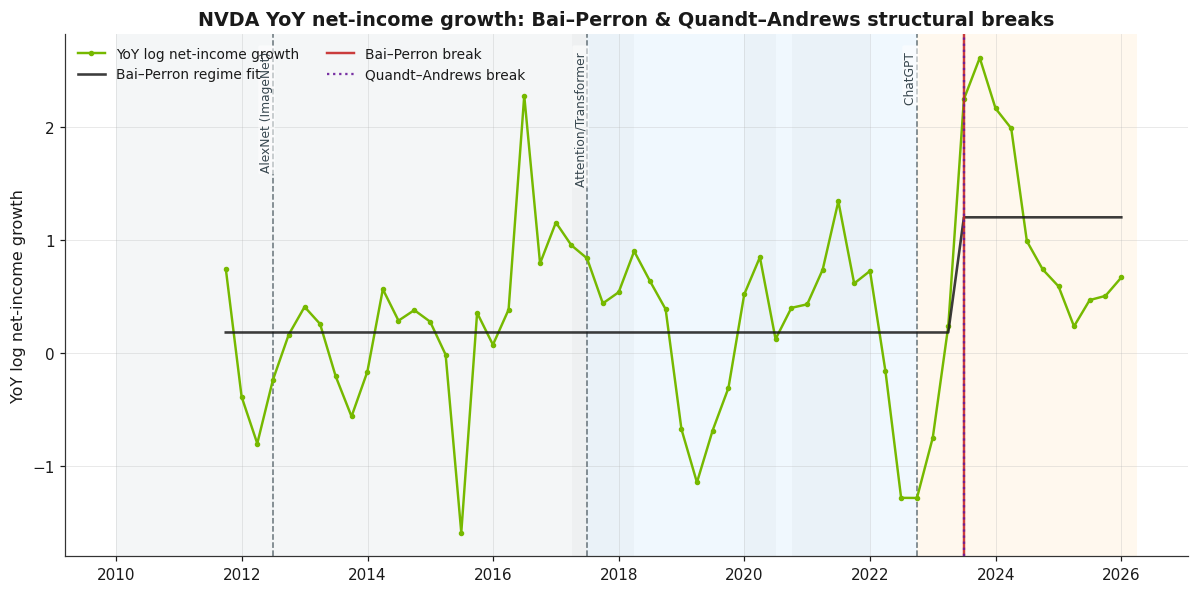

saved figures/14_break_netincome.png


In [13]:
plot_series(S_ni, "14_break_netincome.png", "YoY log net-income growth",
            "NVDA YoY net-income growth: Bai–Perron & Quandt–Andrews structural breaks")

**Reading.** Again both tests put a **single** break at **2023Q2**, double-corroborating
the revenue result. The confidence interval is wider (2022Q1–2024Q1) — net income is the
noisiest and shortest series (58 quarters) — but the point estimate coincides with
revenue and again straddles the ChatGPT marker.

## Combined results

In [14]:
series = [S_price, S_rev, S_ni]

bp_summary = pd.DataFrame([{
    "series": S["name"], "model": S["model"], "n": S["bp"]["n"],
    "breaks (BIC)": S["bp"]["mstar"],
    "break quarters": ", ".join(S["bp_breaks"]) if S["bp_breaks"] else "—",
    "90% CIs": "; ".join(f"{lo}–{hi}" for lo, hi in S["bp_ci"]) if S["bp_ci"] else "—",
} for S in series])

qa_summary = pd.DataFrame([{
    "series": S["name"], "n": S["bp"]["n"], "break (sup-Wald)": S["qa_break"],
    "supF": round(S["qa"]["supF"], 2), "boot p": round(S["qa"]["p"], 3),
    "aveF": round(S["qa"]["aveF"], 2), "expF": round(S["qa"]["expF"], 2),
} for S in series])

align = pd.DataFrame([{
    "series": S["name"],
    "Bai–Perron breaks": ", ".join(S["bp_breaks"]) if S["bp_breaks"] else "—",
    "Quandt–Andrews break": S["qa_break"],
    "nearest milestone": near, "note": note,
} for S, near, note in [
    (S_price, "—", "first break (2015) precedes all milestones; 2018Q4/2022Q2 on confounders"),
    (S_rev,   "ChatGPT 2022Q4", "single break, CI straddles gen-AI onset"),
    (S_ni,    "ChatGPT 2022Q4", "single break, wide CI, coincides with revenue"),
]])

import os
os.makedirs("findings", exist_ok=True)
bp_summary.to_csv("findings/bai_perron_results.csv", index=False)
qa_summary.to_csv("findings/quandt_andrews_results.csv", index=False)

print("=== Bai–Perron (BIC-selected) ==="); display(bp_summary)
print("=== Quandt–Andrews (sup-Wald, single break) ==="); display(qa_summary)
print("=== Break dates vs AI milestones ==="); display(align)

=== Bai–Perron (BIC-selected) ===


,series,model,n,breaks (BIC),break quarters,90% CIs
0,log(price),trend,65,3,"2015Q1, 2018Q4, 2022Q2",2014Q4–2015Q3; 2018Q4–2018Q4; 2022Q2–2022Q2
1,YoY log revenue growth,mean,60,1,2023Q2,2022Q3–2023Q2
2,YoY log net-income growth,mean,58,1,2023Q2,2021Q4–2024Q1


=== Quandt–Andrews (sup-Wald, single break) ===


,series,n,break (sup-Wald),supF,boot p,aveF,expF
0,log(price),65,2015Q4,40.63,0.002,20.28,17.81
1,YoY log revenue growth,60,2023Q2,52.16,0.002,14.92,22.36
2,YoY log net-income growth,58,2023Q2,15.76,0.012,3.76,4.60


=== Break dates vs AI milestones ===


,series,Bai–Perron breaks,Quandt–Andrews break,nearest milestone,note
0,log(price),"2015Q1, 2018Q4, 2022Q2",2015Q4,—,first break (2015) precedes all milestones; 20...
1,YoY log revenue growth,2023Q2,2023Q2,ChatGPT 2022Q4,"single break, CI straddles gen-AI onset"
2,YoY log net-income growth,2023Q2,2023Q2,ChatGPT 2022Q4,"single break, wide CI, coincides with revenue"


## Pillar 1 — Summary (defensible, non-causal)

* **Fundamentals break once, at the generative-AI onset.** NVIDIA's YoY revenue growth
  and YoY net-income growth each contain exactly **one** structural break, both dated
  **2023Q2**, and the result is **double-corroborated**: Bai–Perron's BIC-selected search
  and the Quandt–Andrews sup-Wald — two methodologically different tests — agree to the
  quarter. Both confidence intervals straddle the **ChatGPT marker (2022Q4)**. This is
  the cleanest, most robust result in the analysis.

* **Price re-rates earlier, and not on the AI milestones.** Price shows **three** trend
  breaks (2015Q1, 2018Q4, 2022Q2; dominant single break 2015Q4). The re-rating *begins in
  2015*, before the Transformer and gen-AI markers, and the later breaks fall on the
  late-2018 crypto/market correction and the 2022 macro sell-off rather than on any
  milestone. NVIDIA's generative-AI alignment is therefore a **fundamentals** phenomenon
  (revenue, net income), not a price one.

* **Interpretation is alignment, not cause.** Every break is dated agnostic to its
  driver. The fundamentals' 2023Q2 break is *consistent with* the generative-AI inflection
  but is not evidence of causation; the price breaks are partly entangled with crypto and
  macro confounders shown as grey bands. Establishing causation would require controlling
  for those confounders and a valid counterfactual, which is outside this design.

**Limitations.** Single firm (no control/counterfactual); ~58–65 quarterly observations
(modest power, wide CIs, especially for net income); quarterly fundamentals end 2025Q4
while price runs to 2026Q1. Segment-level (Data Center) corroboration is **not used**: the
annual segment-revenue source could not be verified and is treated as unreliable, so no
segment-based narrative is drawn.

# Pillar 2 · Return Co-movement & Decoupling

**Question.** Does NVIDIA's daily-return co-movement with the rest of the market change
across the three eras — and in the generative-AI era, does it become *distinct*, most
sharply from Intel? The hypothesis is a **ranked** prediction: decoupling is ordered
**INTC > AMD > NDX** (Intel most, the Nasdaq-100 least).

**Framing — distinctiveness, not causation.** Correlation is symmetric: a fall in
NVDA–INTC co-movement is equally consistent with NVIDIA pulling away on AI *and* with
Intel's own decline (its 2022–25 losses). This pillar evidences that NVIDIA's return
behaviour became *distinct*; it does not attribute a cause. Two mechanical caveats are
kept in view: (i) NVIDIA is a large and *growing* constituent of the Nasdaq-100, which
mechanically lifts NVDA–NDX correlation and makes NDX the natural "least-decoupled"
anchor; (ii) overlapping rolling windows induce autocorrelation that inflates naive
significance, so break tests use a moving-block bootstrap and the clean per-era
correlation (no overlap) carries the ranking.

**Method.** Daily log returns at native resolution. *(a) Ranking* — Pearson correlation of
NVDA vs each comparator computed once per era (no rolling, no overlap). *(b) Dating* —
126-day rolling correlation, Fisher-z transformed, sampled monthly, with Bai–Perron (BIC)
and Quandt–Andrews (sup-Wald) breaks and moving-block-bootstrap *p*-values. SOX is
excluded; comparators are INTC, AMD, NDX.

In [15]:
daily = common.load_daily()
PX = daily.pivot_table(index="date", columns="ticker", values="adj_close").sort_index()
RET = np.log(PX / PX.shift(1))
COMP = ["INTC", "AMD", "NDX"]
ERAS = {e.name: (e.start, e.end) for e in common.ERAS}
WIN = 126
print("daily returns:", RET.index.min().date(), "->", RET.index.max().date(), "| comparators:", COMP)

daily returns: 2010-01-04 -> 2026-03-31 | comparators: ['INTC', 'AMD', 'NDX']


### Ranking — per-era correlation (clean, no overlap)

In [16]:
rows = []
for name, (s, e) in ERAS.items():
    sub = RET.loc[(RET.index >= s) & (RET.index <= e), ["NVDA"]+COMP].dropna()
    rows.append({"era": name, **{x: round(sub["NVDA"].corr(sub[x]), 3) for x in COMP}})
era_corr = pd.DataFrame(rows).set_index("era")
era_corr.to_csv("findings/comovement_per_era_corr.csv")
era_corr

,INTC,AMD,NDX
era,,,
Pre-Attention / CNN,0.462,0.430,0.577
Transformer,0.588,0.706,0.809
Generative-AI,0.323,0.627,0.763


In the **Generative-AI** era the ordering is exactly the hypothesised one —
**INTC < AMD < NDX** in correlation, i.e. Intel most decoupled, NDX least. The
Transformer→Gen-AI *drop* is ranked the same way (INTC −0.27, AMD −0.08, NDX −0.05). Note
that against the *Pre-Attention* baseline only Intel falls in absolute terms; AMD and NDX
correlations rose over the decade (market-wide correlation drift + NVIDIA's growing NDX
weight), so "decoupling" here is a Transformer→Gen-AI phenomenon and is absolute only for
Intel.

### Dating — break tests on the rolling correlation

Mean-shift Bai–Perron and Quandt–Andrews on the Fisher-z rolling correlation (monthly),
with 20% trimming and moving-block-bootstrap *p*-values to respect window overlap.

In [17]:
def _ssr_mean_matrix(y):
    n = len(y); cs = np.concatenate([[0], np.cumsum(y)]); cq = np.concatenate([[0], np.cumsum(y*y)])
    M = np.full((n, n), np.inf)
    for i in range(n):
        for j in range(i, n):
            s = cs[j+1]-cs[i]; M[i, j] = (cq[j+1]-cq[i]) - s*s/(j-i+1)
    return M

def bai_perron_mean(y, mmax=5, trim=0.20):
    n = len(y); h = max(2, int(np.floor(trim*n))); M = _ssr_mean_matrix(y); rows = []
    for m in range(mmax+1):
        if (m+1)*h > n: break
        ssr, bps = _dp(M, n, m, h)
        rows.append({"m": m, "ssr": ssr, "bic": n*np.log(ssr/n) + (2*m+1)*np.log(n), "breaks": bps})
    mstar = min(rows, key=lambda r: r["bic"])["m"]
    return rows, mstar, h

def qa_mean(y, trim=0.20):
    n = len(y); h = int(np.floor(trim*n))
    cs = np.concatenate([[0], np.cumsum(y)]); cq = np.concatenate([[0], np.cumsum(y*y)])
    g = y.mean(); Sf = cq[-1] - n*g*g; best = -1; ks = None
    for k in range(h, n-h):
        Sl = cq[k] - cs[k]**2/k; Sr = (cq[n]-cq[k]) - (cs[n]-cs[k])**2/(n-k)
        F = (Sf-(Sl+Sr))/((Sl+Sr)/(n-2))
        if F > best: best, ks = F, k
    return ks, best

def block_boot_p(y, Fobs, h, reps=300, bl=6):
    n = len(y); res = y - y.mean(); nb = int(np.ceil(n/bl)); c = 0
    for _ in range(reps):
        ys = y.mean() + np.concatenate([res[s:s+bl] for s in RNG.integers(0, n-bl+1, nb)])[:n]
        cs = np.concatenate([[0], np.cumsum(ys)]); cq = np.concatenate([[0], np.cumsum(ys*ys)])
        g = ys.mean(); Sf = cq[-1]-n*g*g; best = -1
        for k in range(h, n-h):
            Sl = cq[k]-cs[k]**2/k; Sr = (cq[n]-cq[k])-(cs[n]-cs[k])**2/(n-k)
            best = max(best, (Sf-(Sl+Sr))/((Sl+Sr)/(n-2)))
        if best >= Fobs: c += 1
    return (c+1)/(reps+1)

def fisher(r): return np.arctanh(np.clip(r, -0.999, 0.999))
print("co-movement methods defined")

co-movement methods defined


In [18]:
roll = {}; test_rows = []
for x in COMP:
    pair = RET[["NVDA", x]].dropna()
    rc = pair["NVDA"].rolling(WIN).corr(pair[x]).dropna()
    zm = pd.Series(fisher(rc.values), index=rc.index).resample("ME").last().dropna()
    y = zm.values; ql = list(zm.index)
    bp_rows, mstar, h = bai_perron_mean(y); bps = next(r["breaks"] for r in bp_rows if r["m"] == mstar)
    ks, F = qa_mean(y); p = block_boot_p(y, F, h)
    roll[x] = {"rc": rc, "zm": zm, "bp_idx": bps, "qa_idx": ks}
    test_rows.append({"pair": f"NVDA-{x}", "n (months)": len(y),
                      "BP breaks (BIC)": ", ".join(ql[b].strftime("%Y-%m") for b in bps) if bps else "—",
                      "QA break": ql[ks].strftime("%Y-%m"), "QA supF": round(F, 1),
                      "block-boot p": round(p, 3)})
comove_tests = pd.DataFrame(test_rows)
comove_tests.to_csv("findings/comovement_break_tests.csv", index=False)
comove_tests

,pair,n (months),BP breaks (BIC),QA break,QA supF,block-boot p
0,NVDA-INTC,189,"2013-08, 2018-03, 2023-03",2023-02,34.7,0.070
1,NVDA-AMD,189,"2013-08, 2017-01, 2020-02, 2023-03",2019-03,133.3,0.003
2,NVDA-NDX,189,"2013-08, 2018-02, 2023-03",2018-02,206.4,0.003


The gen-AI-timed break belongs specifically to **Intel**: NVDA–INTC's dominant break is
**2023-02/03**, at the generative-AI onset (block-bootstrap *p*≈0.07 — indicative under the
conservative overlap-robust test). AMD's dominant break is **2019** (its datacenter/Zen-2
ramp) and NDX's is **2018** (rising coupling), neither at gen-AI. So Intel is the one
comparator whose co-movement shift dates to the generative-AI period.

### Charts

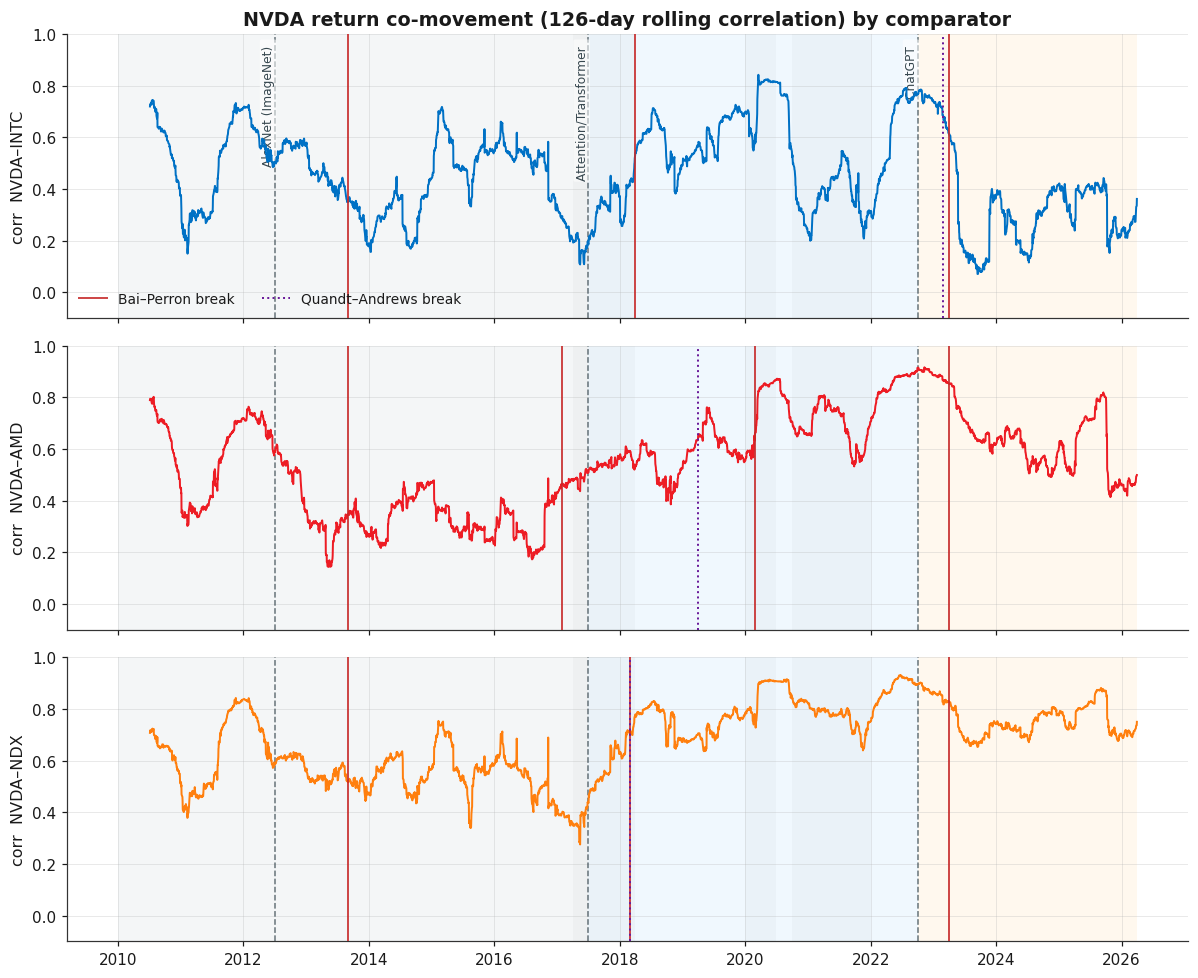

saved figures/15_comovement_small_multiples.png


In [19]:
# 15 — small multiples: one rolling-correlation panel per comparator (shared scale)
fig, axes = plt.subplots(len(COMP), 1, figsize=(11, 9), sharex=True)
for ax, x in zip(axes, COMP):
    rc = roll[x]["rc"]; ql = list(roll[x]["zm"].index)
    common.annotate(ax, milestone_labels=(x == COMP[0]))
    ax.plot(rc.index, rc.values, color=common.color(x), lw=1.3, zorder=4)
    for i, b in enumerate(roll[x]["bp_idx"]):
        ax.axvline(ql[b], color="#c62828", lw=1.3, alpha=0.85, zorder=5,
                   label="Bai–Perron break" if i == 0 else None)
    ax.axvline(ql[roll[x]["qa_idx"]], color="#6a1b9a", lw=1.3, ls=":", zorder=5,
               label="Quandt–Andrews break")
    ax.set_ylim(-0.1, 1.0); ax.set_ylabel(f"corr  NVDA–{x}")
    if x == COMP[0]:
        ax.legend(loc="lower left", ncols=2)
common.style_time_axis(axes[-1], every=2)
axes[0].set_title("NVDA return co-movement (126-day rolling correlation) by comparator")
fig.tight_layout(); fig.savefig(FIG / "15_comovement_small_multiples.png"); plt.show()
print("saved", FIG / "15_comovement_small_multiples.png")

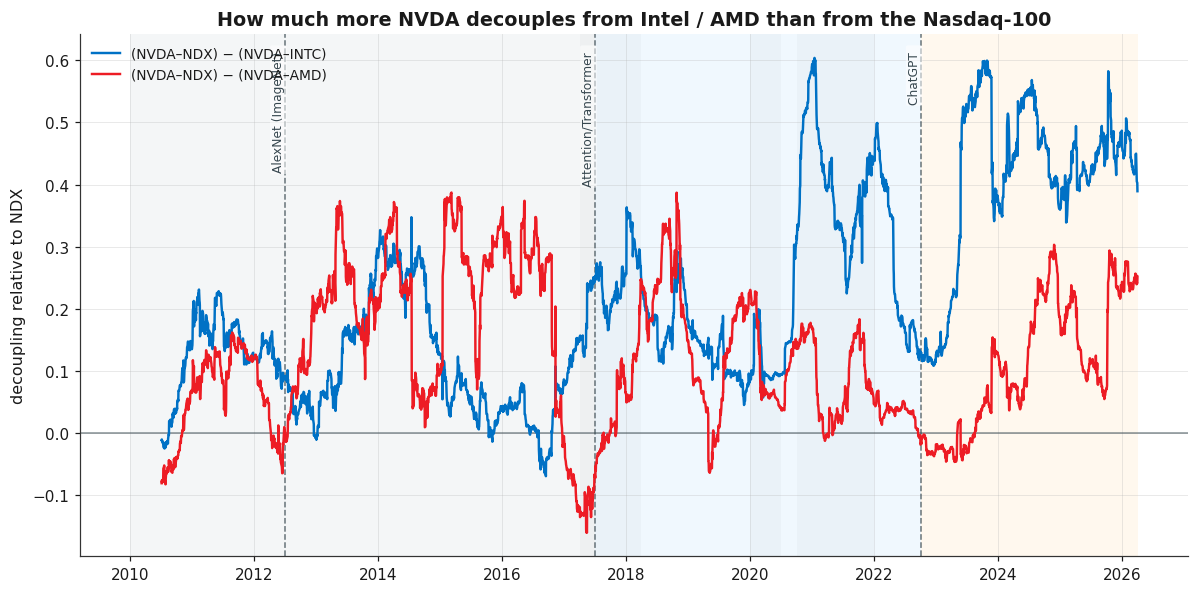

saved figures/16_comovement_spread_ndx.png


In [20]:
# 16 — decoupling spread vs the NDX baseline (>0 = more decoupled from X than from NDX)
ndx_rc = roll["NDX"]["rc"]
fig, ax = plt.subplots()
common.annotate(ax, milestone_labels=True)
ax.axhline(0, color="#37474f", lw=1.0, alpha=0.6)
for x in ["INTC", "AMD"]:
    spread = (ndx_rc - roll[x]["rc"]).dropna()
    ax.plot(spread.index, spread.values, color=common.color(x), lw=1.6,
            label=f"(NVDA–NDX) − (NVDA–{x})")
common.style_time_axis(ax, every=2)
ax.set_ylabel("decoupling relative to NDX")
ax.set_title("How much more NVDA decouples from Intel / AMD than from the Nasdaq-100")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG / "16_comovement_spread_ndx.png"); plt.show()
print("saved", FIG / "16_comovement_spread_ndx.png")

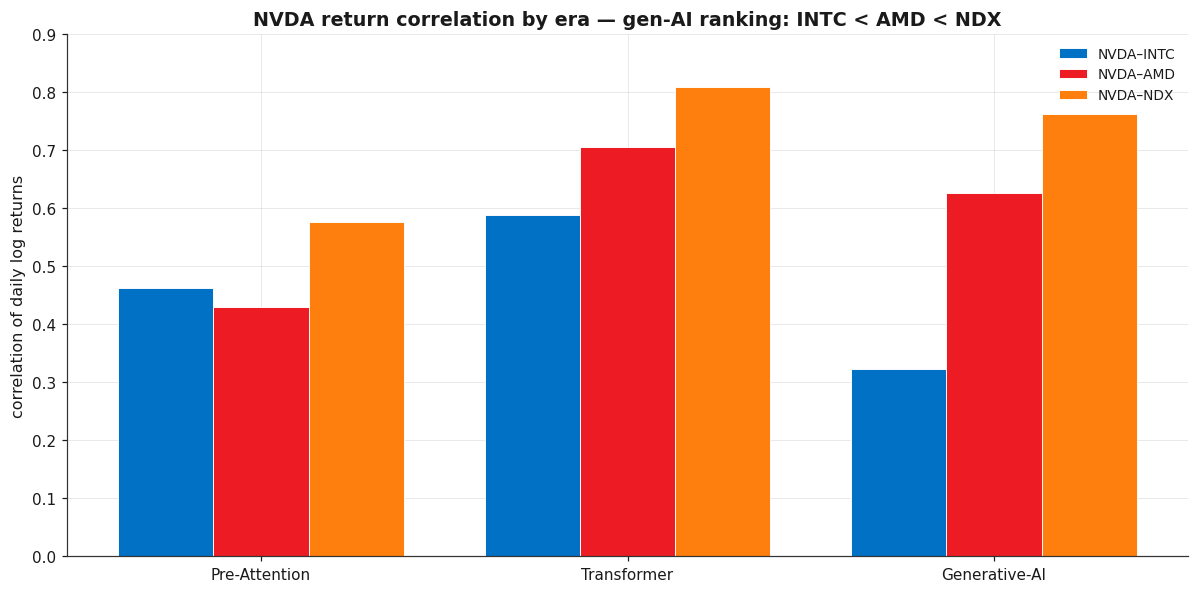

saved figures/17_comovement_per_era_bars.png


In [21]:
# 17 — per-era correlation, grouped bars (the clean ranking)
fig, ax = plt.subplots()
order = list(era_corr.index); xp = np.arange(len(order)); w = 0.26
for i, x in enumerate(COMP):
    ax.bar(xp + (i-1)*w, era_corr[x].values, width=w, label=f"NVDA–{x}",
           color=common.color(x), edgecolor="white", lw=0.6)
ax.set_xticks(xp); ax.set_xticklabels([e.split(" / ")[0] for e in order])
ax.set_ylabel("correlation of daily log returns"); ax.set_ylim(0, 0.9)
ax.set_title("NVDA return correlation by era — gen-AI ranking: INTC < AMD < NDX")
ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "17_comovement_per_era_bars.png"); plt.show()
print("saved", FIG / "17_comovement_per_era_bars.png")

## Pillar 2 — Summary (defensible, non-causal)

* **The ranked prediction holds.** In the generative-AI era NVIDIA's daily-return
  correlation is ordered **INTC 0.32 < AMD 0.63 < NDX 0.76** — Intel most decoupled, the
  Nasdaq-100 least — exactly as hypothesised, and the Transformer→Gen-AI decline is ranked
  the same way (INTC −0.27 > AMD −0.08 > NDX −0.05).
* **The Intel decoupling dates to gen-AI.** Of the three comparators, only NVDA–INTC has
  its dominant co-movement break at the generative-AI onset (≈2023Q1); AMD's dates to its
  2019 ramp and NDX's to 2018. Significance is indicative (*p*≈0.07) under the
  overlap-robust bootstrap; the clean per-era correlations carry the ranking.
* **Distinctiveness, not cause.** The decoupling shows NVIDIA's return behaviour became
  distinct, most sharply from Intel and timed to gen-AI. It is **not** evidence that AI
  *caused* it: the same fall is equally consistent with Intel's own decline, and
  correlation cannot separate the two. Reading it as competitive causation would overstate
  what a symmetric co-movement measure can support.

**Caveats.** NVIDIA's growing weight in the Nasdaq-100 mechanically supports NDX as the
least-decoupled anchor; "decoupling" is a Transformer→Gen-AI effect and is absolute only
for Intel; rolling-window overlap inflates naive significance (mitigated by block
bootstrap, so dating is indicative).